<a href="https://colab.research.google.com/github/Notmefrfr/Notmefrfr/blob/AI/UJICOBA_KE_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gandip486","key":"ffb0cbc284852898dffe2702adc14049"}'}

In [ ]:
import os
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!pip install -q kaggle


In [ ]:
!pip install -q kaggle


In [ ]:
!kaggle datasets download -d rhammell/ships-in-satellite-imagery


Dataset URL: https://www.kaggle.com/datasets/rhammell/ships-in-satellite-imagery
License(s): CC-BY-SA-4.0


In [ ]:
import zipfile

with zipfile.ZipFile("ships-in-satellite-imagery.zip", "r") as zip_ref:
    zip_ref.extractall("ships_dataset")


In [ ]:
import kagglehub
rhammell_ships_in_satellite_imagery_path = kagglehub.dataset_download('rhammell/ships-in-satellite-imagery')

print('Data source import complete.')

100%|██████████| 185M/185M [00:08<00:00, 22.1MB/s]

Extracting files...


Data source import complete.


In [ ]:
!pip install scikeras

In [ ]:
import numpy as np
from numpy import expand_dims
import pandas as pd
import json
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from keras.utils import to_categorical
import keras
from keras import layers
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import RMSprop,Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping

In [ ]:
with open('ships_dataset/shipsnet.json') as data_file:
    dataset = json.load(data_file)
    shipsnet = pd.DataFrame(dataset)
    shipsnet.head()


In [ ]:
shipsnet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   data       4000 non-null   object
 1   labels     4000 non-null   int64 
 2   locations  4000 non-null   object
 3   scene_ids  4000 non-null   object
dtypes: int64(1), object(3)
memory usage: 125.1+ KB


In [ ]:
shipsnet = shipsnet[["data", "labels"]]
shipsnet.head()

,data,labels
0,"[82, 89, 91, 87, 89, 87, 86, 86, 86, 86, 84, 8...",1
1,"[76, 75, 67, 62, 68, 72, 73, 73, 68, 69, 69, 6...",1
2,"[125, 127, 129, 130, 126, 125, 129, 133, 132, ...",1
3,"[102, 99, 113, 106, 96, 102, 105, 105, 103, 10...",1
4,"[78, 76, 74, 78, 79, 79, 79, 82, 86, 85, 83, 8...",1


In [ ]:
len(shipsnet["data"].iloc[0])

19200

In [ ]:
ship_images = shipsnet["labels"].value_counts()[0]
no_ship_images = shipsnet["labels"].value_counts()[1]
print("Number of the ship_images :{}".format(ship_images),"\n")
print("Number of the ship_images :{}".format(no_ship_images))

Number of the ship_images :3000 

Number of the ship_images :1000


In [ ]:
x = np.array(dataset['data']).astype('uint8')
y = np.array(dataset['labels']).astype('uint8')

In [ ]:
x.shape

(4000, 19200)

In [ ]:
x_reshaped = x.reshape([-1, 3, 80, 80])

x_reshaped.shape

(4000, 3, 80, 80)

In [ ]:
x_reshaped = x.reshape([-1, 3, 80, 80]).transpose([0,2,3,1])
x_reshaped.shape

(4000, 80, 80, 3)

In [ ]:
y.shape

(4000,)

In [ ]:
y_reshaped = to_categorical(y, num_classes=2)

y_reshaped.shape

(4000, 2)

In [ ]:
y_reshaped

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

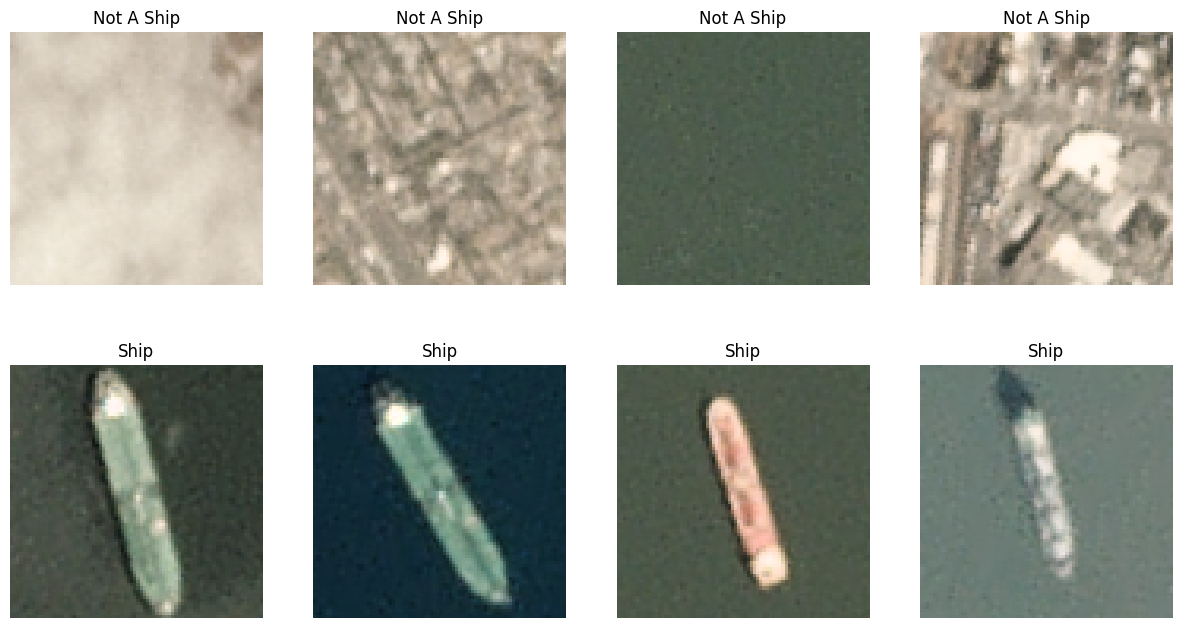

In [ ]:
image_no_ship = x_reshaped[y==0]
image_ship = x_reshaped[y==1]

def plot(a,b):

    plt.figure(figsize=(15, 15))
    for i, k in enumerate(range(1,9)):
        if i < 4:
            plt.subplot(2,4,k)
            plt.title('Not A Ship')
            plt.imshow(image_no_ship[i+2])
            plt.axis("off")
        else:
            plt.subplot(2,4,k)
            plt.title('Ship')
            plt.imshow(image_ship[i+15])
            plt.axis("off")

    plt.subplots_adjust(bottom=0.3, top=0.7, hspace=0.25)

#Implementation of the function

plot(image_no_ship, image_ship)

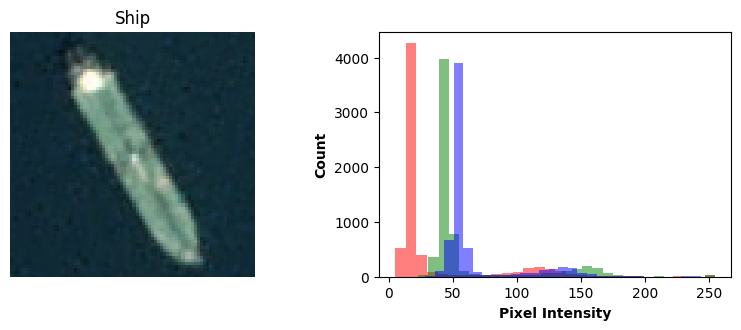

Minimum pixel value of this image: 5
Maximum pixel value of this image: 255


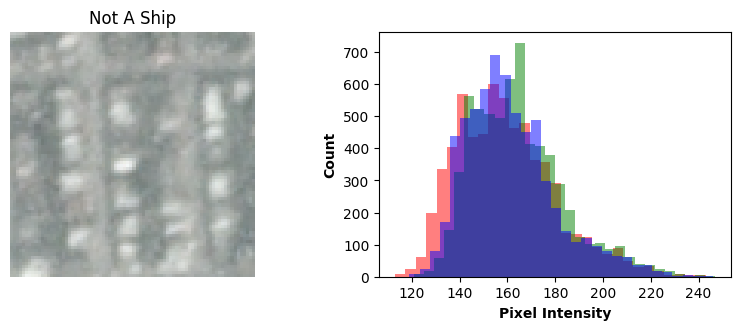

Minimum pixel value of this image: 113
Maximum pixel value of this image: 247


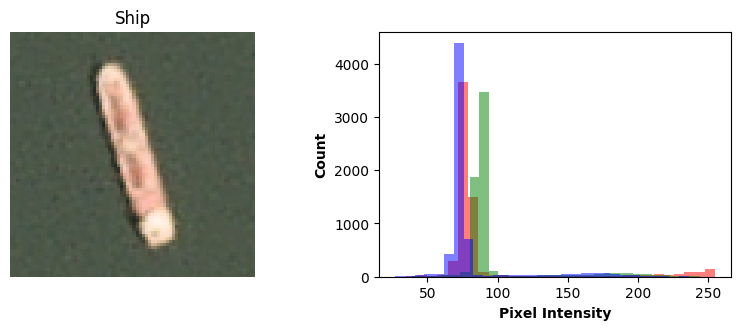

Minimum pixel value of this image: 27
Maximum pixel value of this image: 255


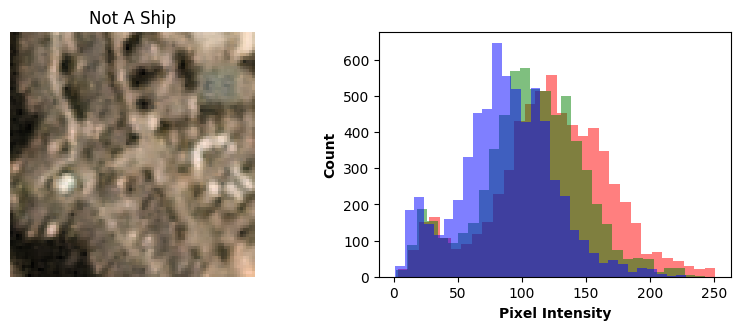

Minimum pixel value of this image: 1
Maximum pixel value of this image: 251


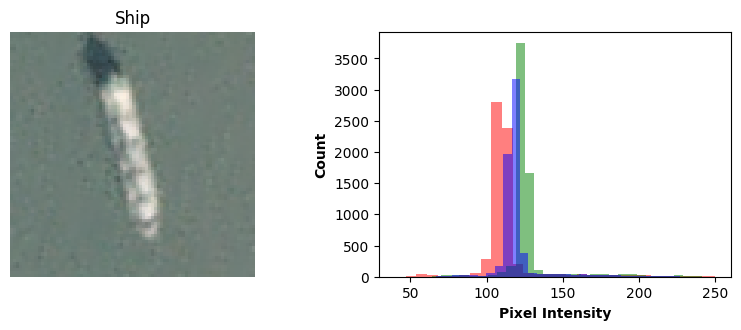

Minimum pixel value of this image: 40
Maximum pixel value of this image: 250


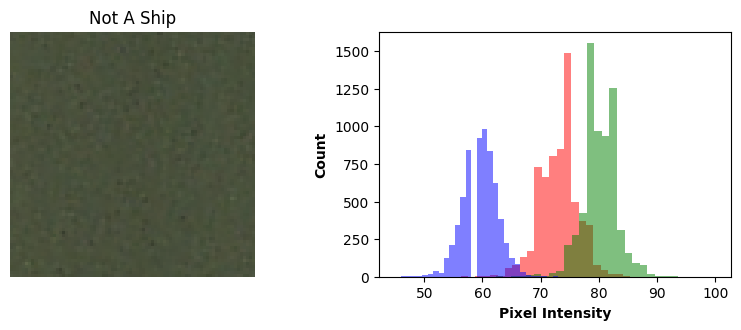

Minimum pixel value of this image: 45
Maximum pixel value of this image: 100


In [ ]:
def plotHistogram(ship, not_ship):

    plt.figure(figsize = (10,7))
    plt.subplot(2,2,1)
    plt.imshow(ship)
    plt.axis('off')
    plt.title('Ship')
    histo = plt.subplot(2,2,2)
    histo.set_ylabel('Count', fontweight = "bold")
    histo.set_xlabel('Pixel Intensity', fontweight = "bold")
    n_bins = 30
    plt.hist(ship[:,:,0].flatten(), bins = n_bins, lw = 0, color = 'r', alpha = 0.5);
    plt.hist(ship[:,:,1].flatten(), bins = n_bins, lw = 0, color = 'g', alpha = 0.5);
    plt.hist(ship[:,:,2].flatten(), bins = n_bins, lw = 0, color = 'b', alpha = 0.5);
    plt.show()
    print("Minimum pixel value of this image: {}".format(ship.min()))
    print("Maximum pixel value of this image: {}".format(ship.max()))
    plt.figure(figsize = (10,7))
    plt.subplot(2,2,3)
    plt.imshow(not_ship)
    plt.axis('off')
    plt.title('Not A Ship')
    histo = plt.subplot(2,2,4)
    histo.set_ylabel('Count', fontweight = "bold")
    histo.set_xlabel('Pixel Intensity', fontweight = "bold")
    n_bins = 30
    plt.hist(not_ship[:,:,0].flatten(), bins = n_bins, lw = 0, color = 'r', alpha = 0.5);
    plt.hist(not_ship[:,:,1].flatten(), bins = n_bins, lw = 0, color = 'g', alpha = 0.5);
    plt.hist(not_ship[:,:,2].flatten(), bins = n_bins, lw = 0, color = 'b', alpha = 0.5);
    plt.show()
    print("Minimum pixel value of this image: {}".format(not_ship.min()))
    print("Maximum pixel value of this image: {}".format(not_ship.max()))
#Implementation of the function

for i in range (20,23):
    plotHistogram(x_reshaped[y==1][i], x_reshaped[y==0][i])

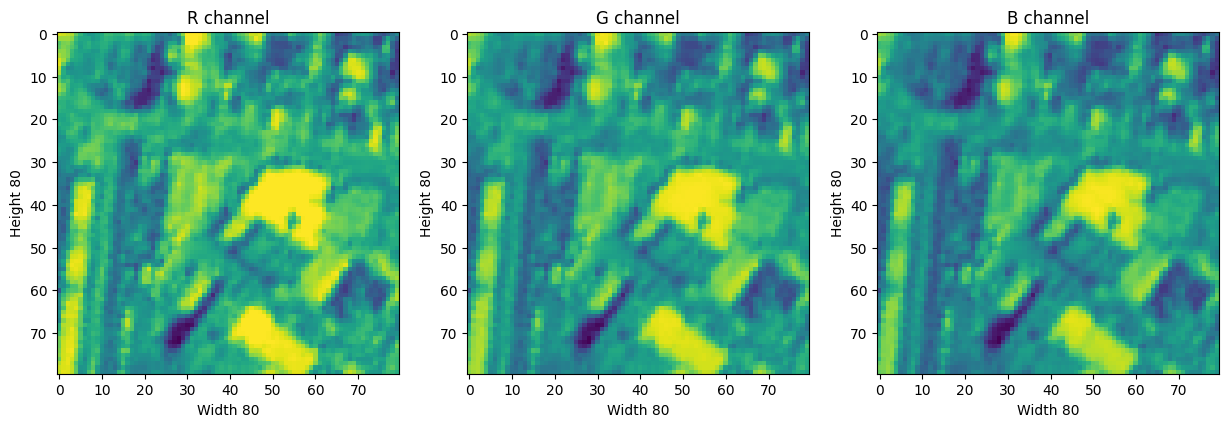

In [ ]:
my_list = [(0, 'R channel'), (1, 'G channel'), (2, 'B channel')]

plt.figure(figsize = (15,15))

for i, k in my_list:
    plt.subplot(1,3,i+1)
    plt.title(k)
    plt.ylabel('Height {}'.format(x_reshaped[y==0][5].shape[0]))
    plt.xlabel('Width {}'.format(x_reshaped[y==0][5].shape[1]))
    plt.imshow(x_reshaped[y==0][5][ : , : , i])

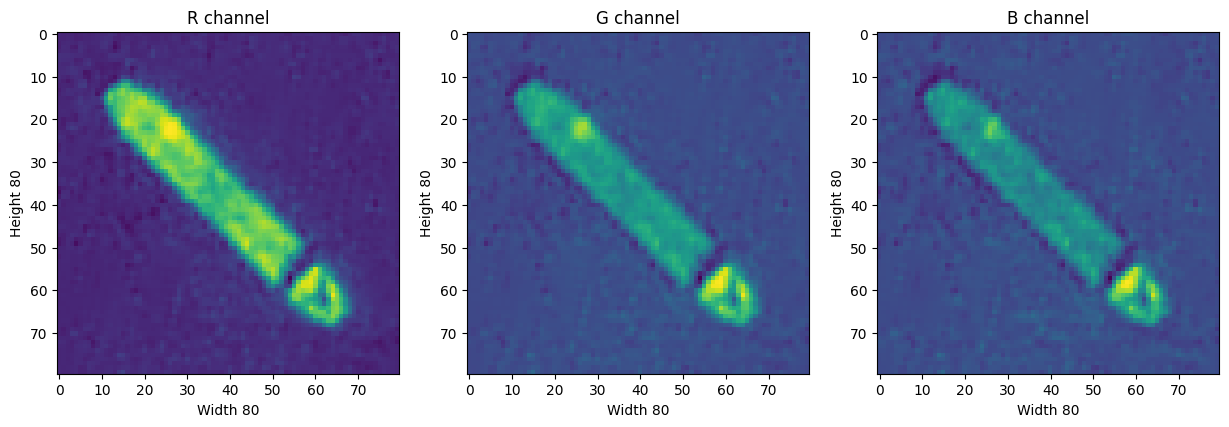

In [ ]:
my_list = [(0, 'R channel'), (1, 'G channel'), (2, 'B channel')]

plt.figure(figsize = (15,15))

for i, k in my_list:
    plt.subplot(1,3,i+1)
    plt.title(k)
    plt.ylabel('Height {}'.format(x_reshaped[y==0][5].shape[0]))
    plt.xlabel('Width {}'.format(x_reshaped[y==0][5].shape[1]))
    plt.imshow(x_reshaped[y==1][5][ : , : , i])

In [ ]:
x_reshaped = x_reshaped / 255

In [ ]:
x_reshaped[0][0][0]

array([0.32156863, 0.36862745, 0.31372549])

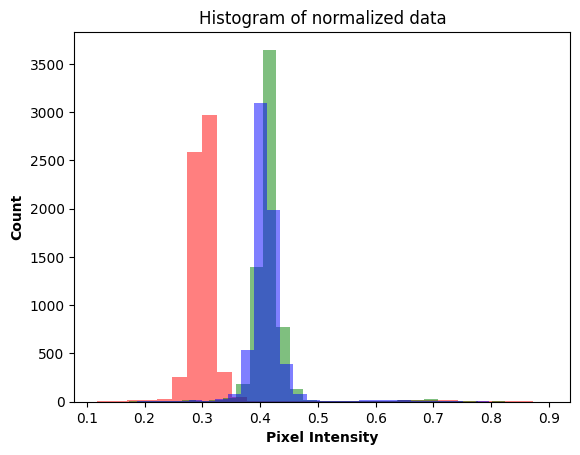

In [ ]:
n_bins = 30
plt.hist(x_reshaped[y == 0][0][:,:,0].flatten(), bins = n_bins, lw = 0, color = 'r', alpha = 0.5);
plt.hist(x_reshaped[y == 0][0][:,:,1].flatten(), bins = n_bins, lw = 0, color = 'g', alpha = 0.5);
plt.hist(x_reshaped[y == 0][0][:,:,2].flatten(), bins = n_bins, lw = 0, color = 'b', alpha = 0.5);
plt.ylabel('Count', fontweight = "bold")
plt.xlabel('Pixel Intensity', fontweight = "bold")
plt.title("Histogram of normalized data")
plt.show()

In [ ]:
x_train_1, x_test, y_train_1, y_test = train_test_split(x_reshaped, y_reshaped,
                                                        test_size = 0.20, random_state = 42)


x_train, x_val, y_train, y_val = train_test_split(x_train_1, y_train_1,
                                                  test_size = 0.25, random_state = 42)


print("x_train shape",x_train.shape)
print("x_test shape",x_test.shape)
print("y_train shape",y_train.shape)
print("y_test shape",y_test.shape)
print("y_train shape",x_val.shape)
print("y_test shape",y_val.shape)

x_train shape (2400, 80, 80, 3)
x_test shape (800, 80, 80, 3)
y_train shape (2400, 2)
y_test shape (800, 2)
y_train shape (800, 80, 80, 3)
y_test shape (800, 2)


In [ ]:
x_train.shape

(2400, 80, 80, 3)

In [ ]:
from keras import callbacks
model = Sequential()
model.add(Flatten(input_shape=[80, 80, 3]))
model.add(Dense(200, activation='relu'))
model.add(Dense(150, activation='relu'))
model.add(Dense(2, activation='sigmoid'))

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
earlystopping = callbacks.EarlyStopping(monitor ="val_loss",
                                        mode ="min", patience = 10,
                                        restore_best_weights = True)

history = model.fit(x_train, y_train, epochs = 100, validation_data=(x_val, y_val), callbacks = [earlystopping])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.6603 - loss: 1.9145 - val_accuracy: 0.8363 - val_loss: 0.3788
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.8435 - loss: 0.4092 - val_accuracy: 0.8775 - val_loss: 0.2967
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8695 - loss: 0.3267 - val_accuracy: 0.8712 - val_loss: 0.3044
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.8622 - loss: 0.3357 - val_accuracy: 0.8938 - val_loss: 0.2662
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.8807 - loss: 0.3134 - val_accuracy: 0.8725 - val_loss: 0.3616
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.8705 - loss: 0.3200 - val_accuracy: 0.8763 - val_loss: 0.3481
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8968 - loss: 0.2859 - val_accuracy: 0.9075 - val_loss: 0.2387
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.8944 - loss: 0.2727 - val_accuracy: 0.

In [ ]:
model.evaluate(x_test, y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9381 - loss: 0.1728


[0.16990654170513153, 0.9412500262260437]

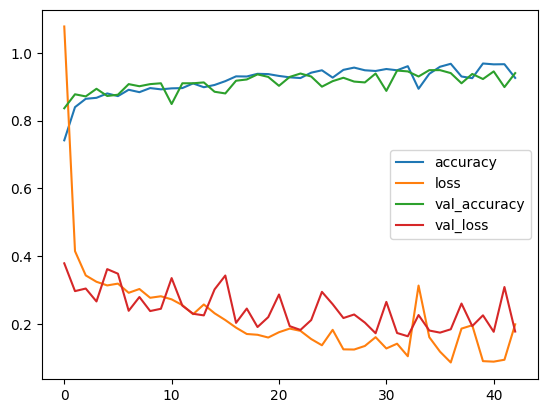

In [ ]:
pd.DataFrame(history.history).plot();

In [ ]:
from keras import callbacks
model = Sequential()
model.add(Flatten(input_shape=[80, 80, 3]))
model.add(Dense(200, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
earlystopping = callbacks.EarlyStopping(monitor ="val_loss",
                                        mode ="min", patience = 10,
                                        restore_best_weights = True)

history = model.fit(x_train, y_train, epochs = 100, validation_data=(x_val, y_val), callbacks = [earlystopping])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.7352 - loss: 1.0447 - val_accuracy: 0.8100 - val_loss: 0.4374
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.8381 - loss: 0.3975 - val_accuracy: 0.8637 - val_loss: 0.3154
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8576 - loss: 0.3543 - val_accuracy: 0.8350 - val_loss: 0.4339
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.8565 - loss: 0.3491 - val_accuracy: 0.8813 - val_loss: 0.2754
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.8757 - loss: 0.3087 - val_accuracy: 0.8938 - val_loss: 0.2582
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.8992 - loss: 0.2733 - val_accuracy: 0.8925 - val_loss: 0.2753
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.8832 - loss: 0.2844 - val_accuracy: 0.8975 - val_loss: 0.2461
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.8903 - loss: 0.2658 - val_accuracy: 0.

In [ ]:
model.evaluate(x_test, y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8990 - loss: 0.2346


[0.2429541051387787, 0.8962500095367432]

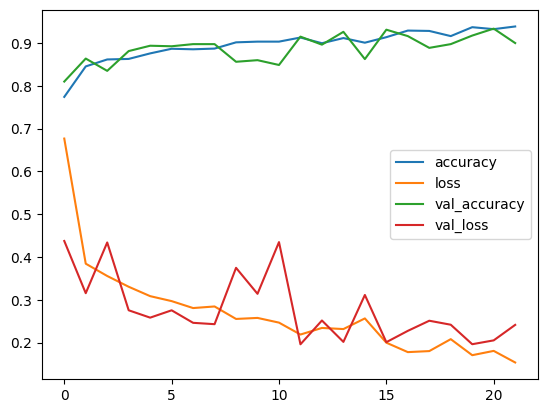

In [ ]:
pd.DataFrame(history.history).plot();

In [ ]:
prediction = model.predict(x_test)
pd.Series(prediction[0], index=["Not A Ship", "Ship"])

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


,0
Not A Ship,0.187027
Ship,0.812973


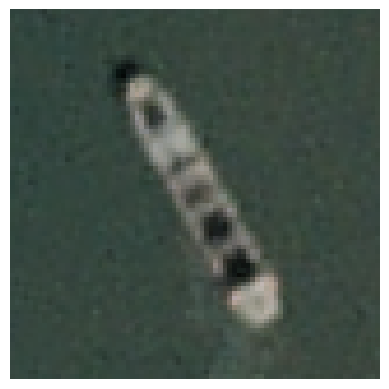

In [ ]:
plt.imshow(x_test[0])
plt.axis("off")
plt.show()

In [ ]:
predicted_data = pd.DataFrame(prediction, columns=["Not A Ship", "Ship"])
predicted_data.head(3)

,Not A Ship,Ship
0,0.187027,0.812973
1,0.996755,0.003245
2,0.089480,0.910520


In [ ]:
predicted_data['There is a Ship'] = y_test[:, 1]
predicted_data.head()

,Not A Ship,Ship,There is a Ship
0,0.187027,0.812973,1.0
1,0.996755,0.003245,0.0
2,0.089480,0.910520,1.0
3,0.074642,0.925358,0.0
4,0.999180,0.000820,0.0


In [ ]:
predicted_data["Difference"] = predicted_data["Ship"] - predicted_data["There is a Ship"]
predicted_data

,Not A Ship,Ship,There is a Ship,Difference
0,0.187027,0.812973,1.0,-0.187027
1,0.996755,0.003245,0.0,0.003245
2,0.089480,0.910520,1.0,-0.089480
3,0.074642,0.925358,0.0,0.925358
4,0.999180,0.000820,0.0,0.000820
...,...,...,...,...
795,0.307719,0.692281,0.0,0.692281
796,0.262961,0.737039,1.0,-0.262961
797,0.908241,0.091759,0.0,0.091759
798,0.998496,0.001504,0.0,0.001504


In [ ]:
predicted_data.sort_values('Difference', ascending=False).head(10)

,Not A Ship,Ship,There is a Ship,Difference
528,0.023549,0.976452,0.0,0.976452
413,0.026692,0.973308,0.0,0.973308
628,0.052519,0.947481,0.0,0.947481
662,0.066730,0.933270,0.0,0.933270
3,0.074642,0.925358,0.0,0.925358
221,0.079356,0.920644,0.0,0.920644
657,0.100451,0.899549,0.0,0.899549
484,0.101654,0.898346,0.0,0.898346
207,0.105461,0.894539,0.0,0.894539
783,0.112226,0.887774,0.0,0.887774


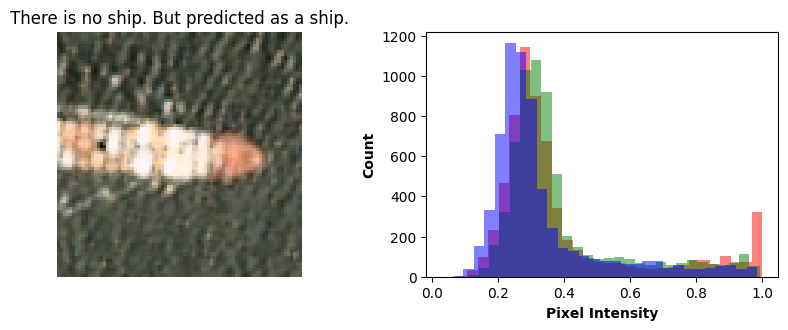

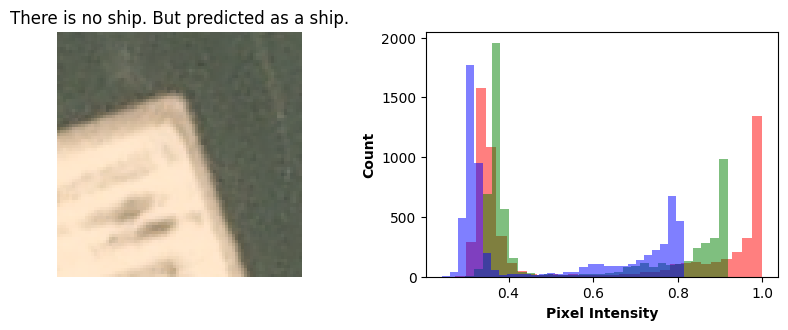

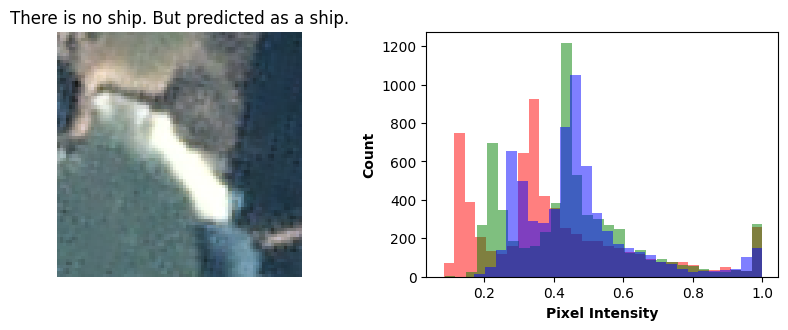

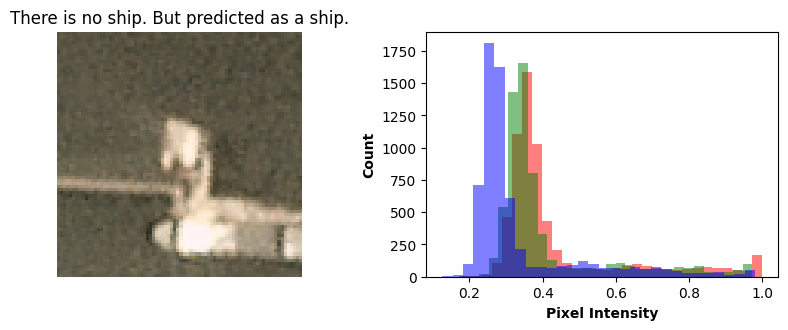

In [ ]:
indexes = predicted_data.sort_values('Difference', ascending = False).head(4).index.to_list()

def plotHistogram(image_index):

    plt.figure(figsize = (10,7))
    plt.subplot(2,2,1)
    plt.imshow(x_test[image_index])
    plt.axis('off')
    plt.title('There is no ship. But predicted as a ship.')
    histo = plt.subplot(2,2,2)
    histo.set_ylabel('Count', fontweight = "bold")
    histo.set_xlabel('Pixel Intensity', fontweight = "bold")
    n_bins = 30
    plt.hist(x_test[image_index][:,:,0].flatten(), bins = n_bins, lw = 0, color = 'r', alpha = 0.5);
    plt.hist(x_test[image_index][:,:,1].flatten(), bins = n_bins, lw = 0, color = 'g', alpha = 0.5);
    plt.hist(x_test[image_index][:,:,2].flatten(), bins = n_bins, lw = 0, color = 'b', alpha = 0.5);
    plt.show()


#Implementation of the function

for i in indexes:
    plotHistogram(i)

In [ ]:
predicted_data.sort_values('Difference', ascending=True).head(10)

,Not A Ship,Ship,There is a Ship,Difference
537,0.997224,0.002776,1.0,-0.997224
100,0.982876,0.017124,1.0,-0.982876
578,0.967854,0.032145,1.0,-0.967855
322,0.930266,0.069734,1.0,-0.930266
249,0.899085,0.100915,1.0,-0.899085
518,0.873394,0.126606,1.0,-0.873394
36,0.860063,0.139937,1.0,-0.860063
331,0.854918,0.145082,1.0,-0.854918
247,0.827122,0.172878,1.0,-0.827122
365,0.819914,0.180086,1.0,-0.819914


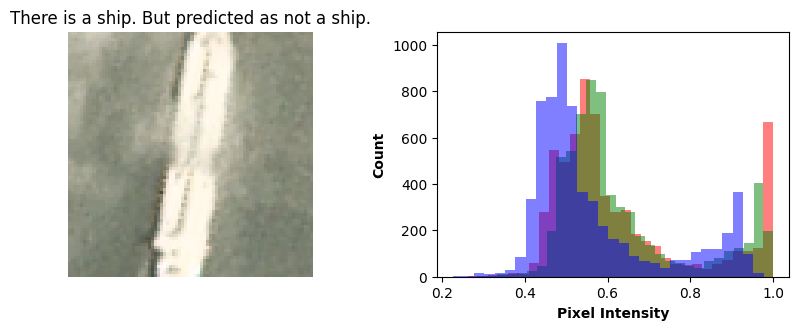

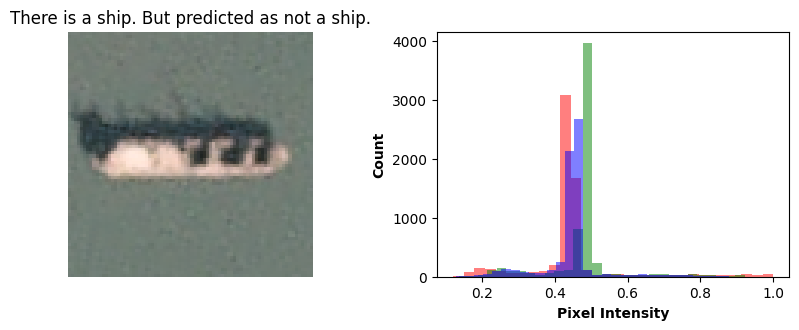

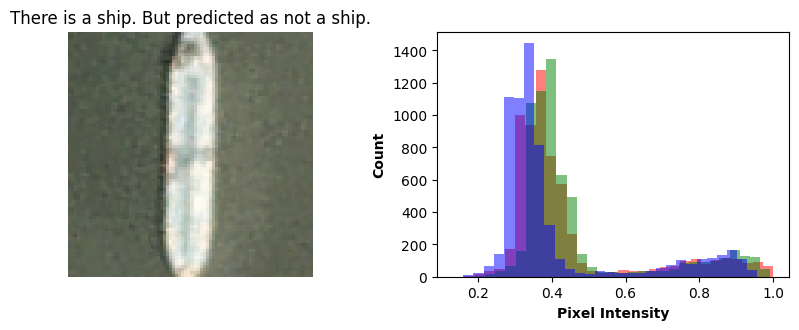

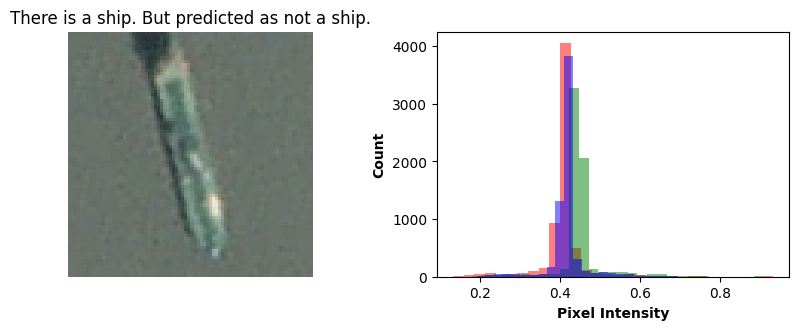

In [ ]:
indexes = predicted_data.sort_values('Difference', ascending = True).head(4).index.to_list()

def plotHistogram(image_index):

    plt.figure(figsize = (10,7))
    plt.subplot(2,2,1)
    plt.imshow(x_test[image_index])
    plt.axis('off')
    plt.title('There is a ship. But predicted as not a ship.')
    histo = plt.subplot(2,2,2)
    histo.set_ylabel('Count', fontweight = "bold")
    histo.set_xlabel('Pixel Intensity', fontweight = "bold")
    n_bins = 30
    plt.hist(x_test[image_index][:,:,0].flatten(), bins = n_bins, lw = 0, color = 'r', alpha = 0.5);
    plt.hist(x_test[image_index][:,:,1].flatten(), bins = n_bins, lw = 0, color = 'g', alpha = 0.5);
    plt.hist(x_test[image_index][:,:,2].flatten(), bins = n_bins, lw = 0, color = 'b', alpha = 0.5);
    plt.show()


#Implementation of the function

for i in indexes:
    plotHistogram(i)

In [ ]:
from keras import callbacks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.optimizers import Adam
model = Sequential()
#
model.add(Conv2D(filters = 64, kernel_size = (4,4),padding = 'Same',
                 activation ='relu', input_shape = (80,80,3)))
model.add(MaxPool2D(pool_size=(5,5)))
model.add(Dropout(0.25))
#
model.add(Conv2D(filters = 32, kernel_size = (3,3),padding = 'Same',
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(3,3), strides=(1,1)))
model.add(Dropout(0.25))
#
model.add(Conv2D(filters = 16, kernel_size = (2,2),padding = 'Same',
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(3,3), strides=(1,1)))
model.add(Dropout(0.25))

# Fully connected
model.add(Flatten())
model.add(Dense(200, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(100, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(100, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(50, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(2, activation = "softmax"))

optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])

earlystopping = callbacks.EarlyStopping(monitor ="val_loss",
                                        mode ="min", patience = 10,
                                        restore_best_weights = True)
history = model.fit(x_train, y_train, epochs = 100, validation_data=(x_val, y_val), callbacks = [earlystopping])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 388ms/step - accuracy: 0.7094 - loss: 0.6251 - val_accuracy: 0.7513 - val_loss: 0.5894
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 38s 345ms/step - accuracy: 0.7494 - loss: 0.5328 - val_accuracy: 0.8175 - val_loss: 0.4507
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 43s 381ms/step - accuracy: 0.8229 - loss: 0.4048 - val_accuracy: 0.8863 - val_loss: 0.2916
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 39s 357ms/step - accuracy: 0.8637 - loss: 0.3294 - val_accuracy: 0.8975 - val_loss: 0.2764
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 39s 336ms/step - accuracy: 0.8772 - loss: 0.2922 - val_accuracy: 0.9038 - val_loss: 0.2735
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 44s 374ms/step - accuracy: 0.9044 - loss: 0.2404 - val_accuracy: 0.9212 - val_loss: 0.1953
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 37s 326ms/step - accuracy: 0.9082 - loss: 0.2160 - val_accuracy: 0.9250 - val_loss: 0.1997
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 473ms/step - accuracy: 0.9298 - loss: 0.1756 - 

In [ ]:
model.evaluate(x_test, y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.9812 - loss: 0.0862


[0.07874426245689392, 0.9787499904632568]

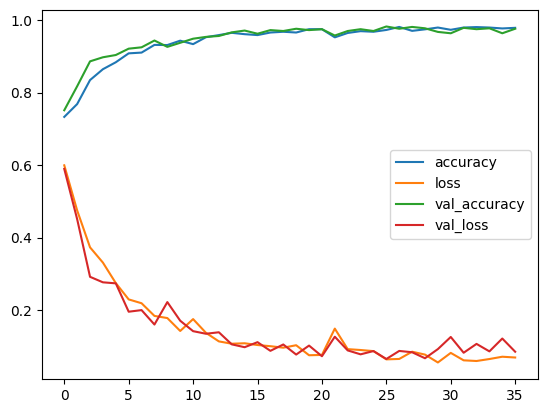

In [ ]:
pd.DataFrame(history.history).plot();

In [ ]:
datagen = ImageDataGenerator(
        featurewise_center=False,
        samplewise_center=False,
        featurewise_std_normalization=False,
        samplewise_std_normalization=False,
        zca_whitening=False,
        rotation_range=5,
        zoom_range = 0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=False,
        vertical_flip=False)

datagen.fit(x_train)

Data range before expand: 0.3843137254901961 0.9254901960784314
Shape after expand dims: (80, 80, 3)


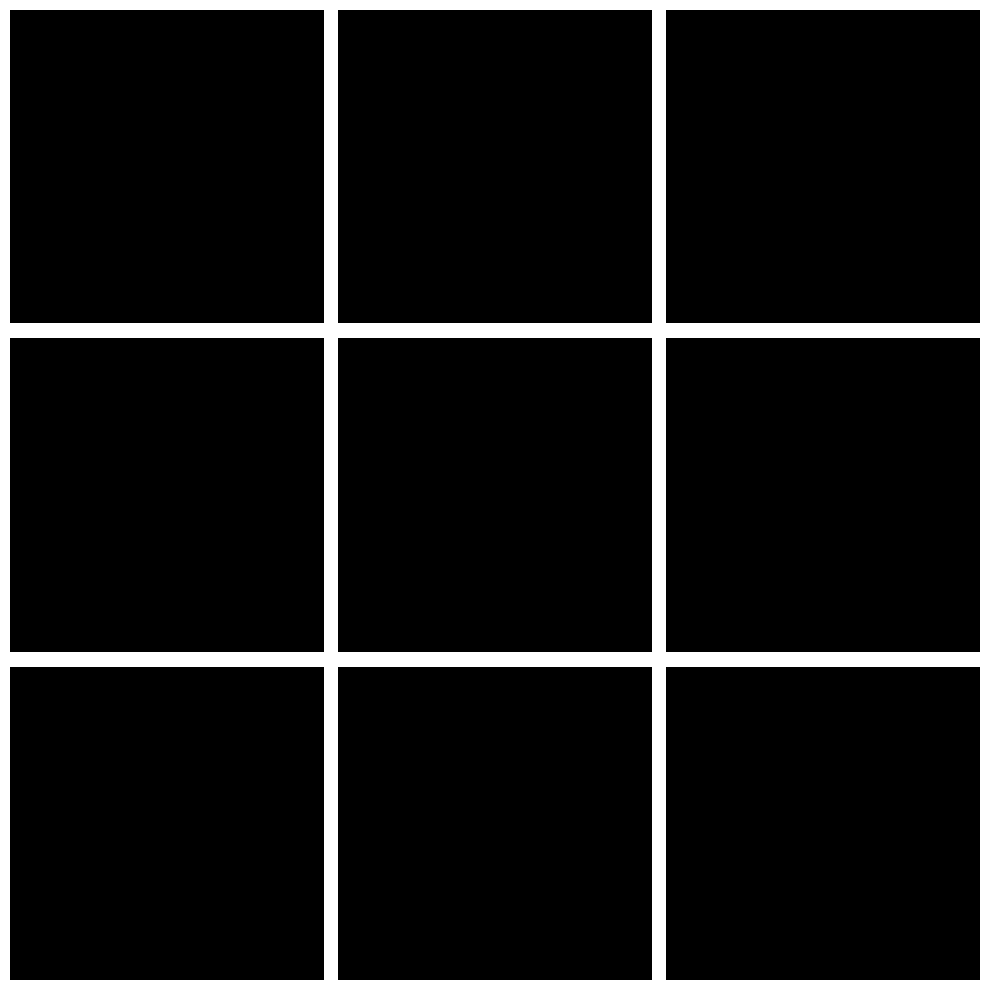

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from numpy import expand_dims
import matplotlib.pyplot as plt
import numpy as np

# Ambil satu gambar dari data
data = x_reshaped[y==1][15]

# Cek nilai minimum dan maksimum dulu (biar tahu gambar ini valid)
print("Data range before expand:", data.min(), data.max())

# Jika data bentuknya (28, 28), ubah jadi (28, 28, 1) agar cocok untuk augmentasi
if len(data.shape) == 2:
    data = np.expand_dims(data, axis=-1)

# Cek ulang bentuk data
print("Shape after expand dims:", data.shape)

# Perlu 3 channel agar augmentasi tidak salah interpretasi (jadi RGB)
if data.shape[-1] == 1:
    data = np.repeat(data, 3, axis=-1)

# Expand dimension supaya jadi 1 sample
samples = expand_dims(data, 0)

# Buat image data augmentation
datag = ImageDataGenerator(
    brightness_range=[0.8, 1.2],  # jangan terlalu gelap
    zoom_range=[0.9, 1.1],
    horizontal_flip=True,
    rotation_range=30
)

# Siapkan iterator
it = datag.flow(samples, batch_size=1)

# Tampilkan hasil augmentasi
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    batch = next(it)
    image = batch[0].astype('uint8')
    plt.imshow(image)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
history = model.fit(datagen.flow(x_train, y_train), epochs = 100,
                    validation_data=(x_val, y_val), callbacks = [earlystopping])

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 438ms/step - accuracy: 0.9160 - loss: 0.2934 - val_accuracy: 0.9688 - val_loss: 0.1103
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 425ms/step - accuracy: 0.9385 - loss: 0.1638 - val_accuracy: 0.9762 - val_loss: 0.0997
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 381ms/step - accuracy: 0.9453 - loss: 0.1529 - val_accuracy: 0.9750 - val_loss: 0.0934
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 477ms/step - accuracy: 0.9492 - loss: 0.1444 - val_accuracy: 0.9675 - val_loss: 0.1093
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 420ms/step - accuracy: 0.9342 - loss: 0.1826 - val_accuracy: 0.9712 - val_loss: 0.0968
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 381ms/step - accuracy: 0.9493 - loss: 0.1368 - val_accuracy: 0.9787 - val_loss: 0.0910
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 528ms/step - accuracy: 0.9589 - loss: 0.1075 - val_accuracy: 0.9887 - val_loss: 0.0703
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 434ms/step - accuracy: 0.9606 - loss: 0.1124 - val_accuracy

In [ ]:
model.evaluate(x_test, y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9801 - loss: 0.0676


[0.07215030491352081, 0.981249988079071]

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step

Test Accuracy Score :  0.98125 



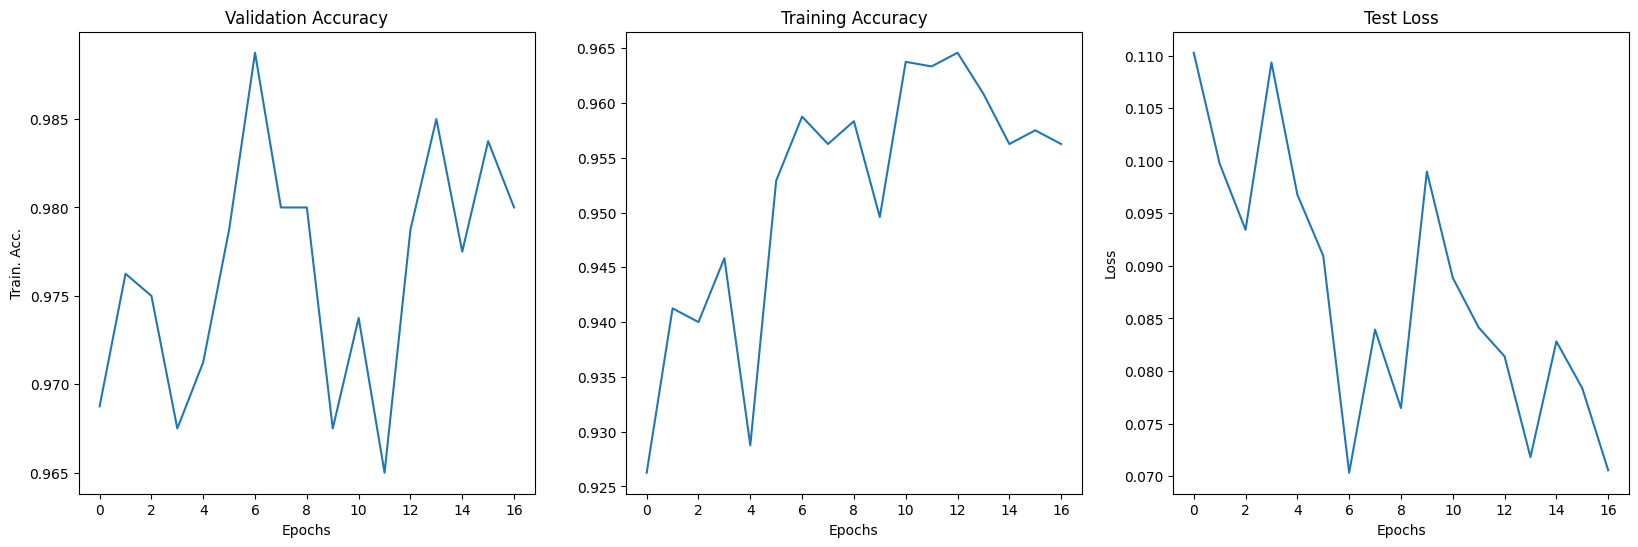

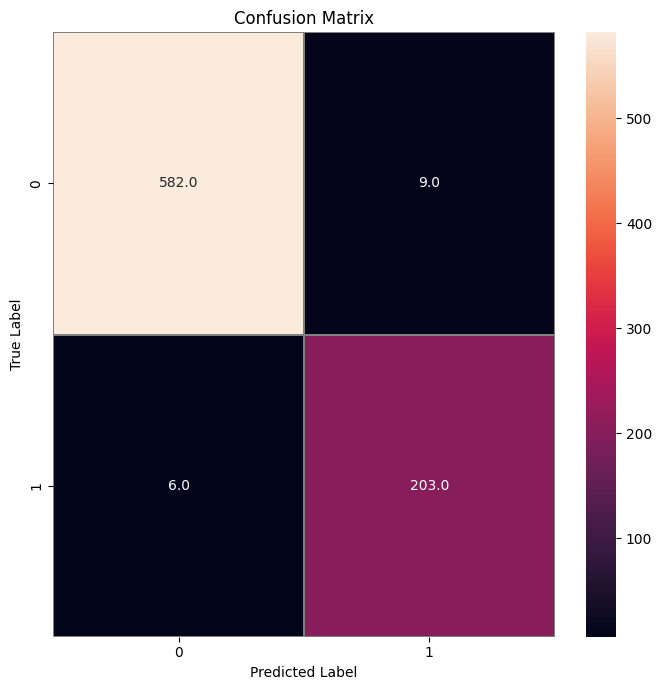

In [ ]:
from sklearn import metrics
import seaborn as sns
Y_pred = model.predict(x_test)
# Convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(Y_pred,axis = 1)
# Convert validation observations to one hot vectors
Y_true = np.argmax(y_test,axis = 1)
# Compute the confusion matrix

print("\n""Test Accuracy Score : ",metrics.accuracy_score(Y_true, Y_pred_classes),"\n")

fig, axis = plt.subplots(1, 3, figsize=(20,6))
axis[0].plot(history.history['val_accuracy'], label='val_acc')
axis[0].set_title("Validation Accuracy")
axis[0].set_xlabel("Epochs")
axis[0].set_ylabel("Val. Acc.")
axis[1].plot(history.history['accuracy'], label='acc')
axis[1].set_title("Training Accuracy")
axis[1].set_xlabel("Epochs")
axis[0].set_ylabel("Train. Acc.")
axis[2].plot(history.history['val_loss'], label='val_loss')
axis[2].set_title("Test Loss")
axis[2].set_xlabel("Epochs")
axis[2].set_ylabel("Loss")

plt.show()

confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
# Plot the confusion matrix
f,ax = plt.subplots(figsize=(7, 7))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.01,linecolor="gray", fmt= '.1f',ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()

plt.show()

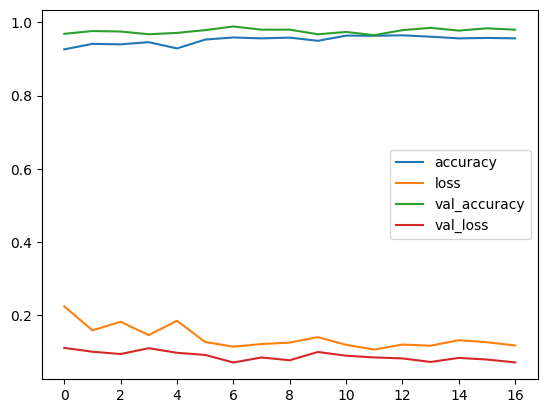

In [ ]:
pd.DataFrame(history.history).plot();

In [ ]:
prediction = model.predict(x_test)
pd.Series(prediction[0], index=["Not A Ship", "Ship"])

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step


,0
Not A Ship,0.025475
Ship,0.974525


In [ ]:
predicted_data = pd.DataFrame(prediction, columns=["Not A Ship", "Ship"])
predicted_data.head(3)

,Not A Ship,Ship
0,0.025475,9.745254e-01
1,1.000000,9.505687e-11
2,0.017879,9.821205e-01


In [ ]:
y_test_data = pd.DataFrame(y_test, columns=["Not A Ship", "Ship"])
y_test_data.head(3)

,Not A Ship,Ship
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0


In [ ]:
predicted_data['There is a Ship'] = y_test[:, 1]
predicted_data.head()

,Not A Ship,Ship,There is a Ship
0,0.025475,9.745254e-01,1.0
1,1.000000,9.505687e-11,0.0
2,0.017879,9.821205e-01,1.0
3,0.878782,1.212179e-01,0.0
4,1.000000,1.948796e-18,0.0


In [ ]:
predicted_data["Difference"] = predicted_data["Ship"] - predicted_data["There is a Ship"]
predicted_data

,Not A Ship,Ship,There is a Ship,Difference
0,0.025475,9.745254e-01,1.0,-2.547461e-02
1,1.000000,9.505687e-11,0.0,9.505687e-11
2,0.017879,9.821205e-01,1.0,-1.787949e-02
3,0.878782,1.212179e-01,0.0,1.212179e-01
4,1.000000,1.948796e-18,0.0,1.948796e-18
...,...,...,...,...
795,0.721661,2.783389e-01,0.0,2.783389e-01
796,0.180321,8.196791e-01,1.0,-1.803209e-01
797,0.999926,7.376094e-05,0.0,7.376094e-05
798,1.000000,1.431039e-17,0.0,1.431039e-17


In [ ]:
predicted_data.sort_values('Difference', ascending=False).head(10)

,Not A Ship,Ship,There is a Ship,Difference
628,0.038436,0.961564,0.0,0.961564
461,0.148078,0.851923,0.0,0.851923
280,0.176621,0.823379,0.0,0.823379
217,0.267649,0.732351,0.0,0.732351
747,0.290361,0.709639,0.0,0.709639
564,0.362248,0.637752,0.0,0.637752
379,0.380669,0.619331,0.0,0.619331
699,0.400719,0.599281,0.0,0.599281
185,0.436836,0.563164,0.0,0.563164
192,0.504726,0.495274,0.0,0.495274


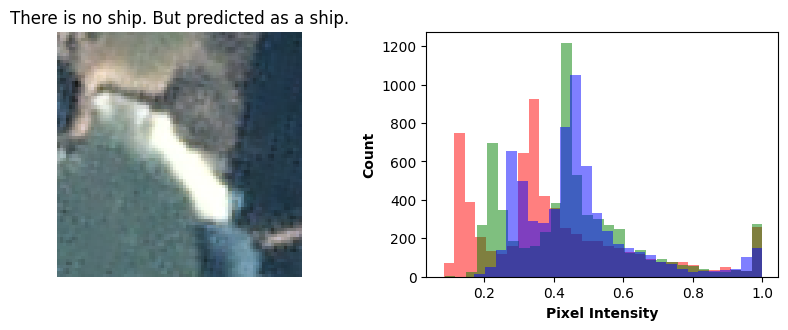

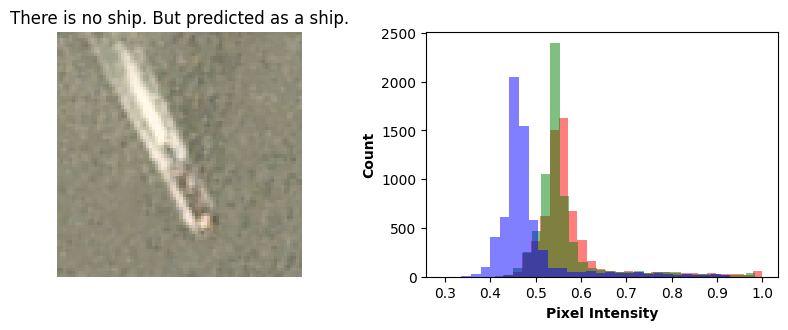

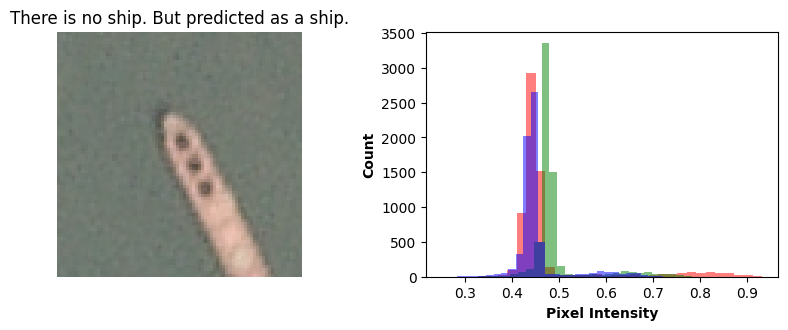

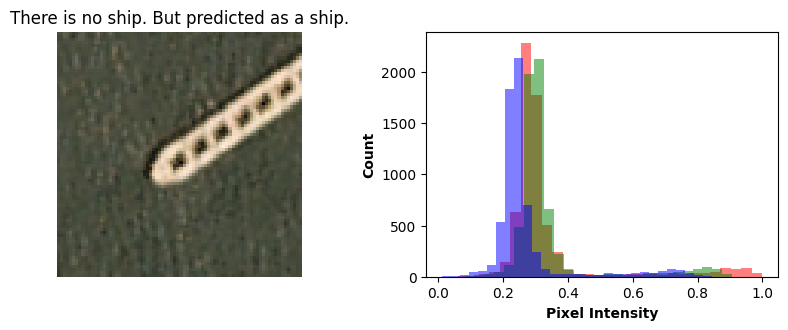

In [ ]:
indexes = predicted_data.sort_values('Difference', ascending = False).head(4).index.to_list()

def plotHistogram(image_index):

    plt.figure(figsize = (10,7))
    plt.subplot(2,2,1)
    plt.imshow(x_test[image_index])
    plt.axis('off')
    plt.title('There is no ship. But predicted as a ship.')
    histo = plt.subplot(2,2,2)
    histo.set_ylabel('Count', fontweight = "bold")
    histo.set_xlabel('Pixel Intensity', fontweight = "bold")
    n_bins = 30
    plt.hist(x_test[image_index][:,:,0].flatten(), bins = n_bins, lw = 0, color = 'r', alpha = 0.5);
    plt.hist(x_test[image_index][:,:,1].flatten(), bins = n_bins, lw = 0, color = 'g', alpha = 0.5);
    plt.hist(x_test[image_index][:,:,2].flatten(), bins = n_bins, lw = 0, color = 'b', alpha = 0.5);
    plt.show()


#Implementation of the function

for i in indexes:
    plotHistogram(i)